# 06 — H6 arc semantics audit (human review)

Main-couple vs non-couple conflict, and topic × position weights \(W_{tkr}\).
High `4.4` label fidelity ≠ “is it **main-couple** conflict?”

Saved audits + packets only. Rating cells stay blinded; sentence tertiles are visible
because H6 is position-aware.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import review_display as rd
from src.stage11_refined_construct_analysis.analysis.constructs import normalize_code

ctx = nh.setup("06_h6_arc_semantics_audit")
cfg = ctx.cfg
HYP = "H6"
CODE_COL = "arc_role"

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/06_h6_arc_semantics_audit


## 1. Overview — arc roles with topic labels

In [2]:
master = nh.load_master(cfg)
h6 = master[master[CODE_COL].notna()].copy()
h6["code_norm"] = h6[CODE_COL].map(normalize_code)
print(f"H6-coded topics: {len(h6)}")

overview = rd.annotation_overview(
    h6,
    CODE_COL,
    extra_cols=["main_couple_prob", "non_couple_prob", "unclear_prob"],
)
display(
    overview[
        [
            "topic",
            "taxonomy",
            "code",
            "code_norm",
            "main_couple_prob",
            "non_couple_prob",
        ]
    ]
)
ctx.save_table(overview, "h6_topic_overview_labeled")
display(h6[CODE_COL].value_counts().head(25).to_frame("n"))
display(h6["code_norm"].value_counts(dropna=False).to_frame("n_norm"))

H6-coded topics: 29


,topic,taxonomy,code,code_norm,main_couple_prob,non_couple_prob
0,285 — Confessing Years of Hatred,3.2 — Negative Emotions & Distress,ARC_2,ARC_2,0.8500,0.1000
1,37 — Defending A Close Friendship,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_1,ARC_1,0.8500,0.1000
2,94 — Caught in A Lie,"4.3 — Secrets, Misunderstandings & Hidden Info...",MIXED,None,0.8500,0.1000
3,109 — Seeing Past A Guarded Identity,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_5,ARC_5,0.8500,0.1000
4,121 — Revealing Plans to The Prince,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_0,ARC_0,0.1000,0.8000
5,130 — Revealing A Secret Plan,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_0,ARC_0,0.1000,0.8000
6,177 — Seeing Past A Hidden Identity,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_1,ARC_1,0.8500,0.1000
7,194 — Promising to Keep A Secret,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_5,ARC_5,0.8500,0.1000
8,214 — Demanding to Know What Happened,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_1,ARC_1,0.8500,0.1000
9,237 — Hiding Someone Before He Arrives,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_5,ARC_5,0.8500,0.1000


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/06_h6_arc_semantics_audit/tables/h6_topic_overview_labeled.csv  (29 rows)


,n
arc_role,
ARC_1,7
ARC_0,6
MIXED,5
ARC_5,4
ARC_10,3
ARC_4,2
ARC_6,1
ARC_2,1


,n_norm
code_norm,
ARC_1,7
ARC_0,6
None,5
ARC_5,4
ARC_10,3
ARC_4,2
ARC_6,1
ARC_2,1


## 2. Lexical vs contextual agreement

In [3]:
lex = nh.load_audit_jsonl(cfg, HYP, "A")
ctxu = nh.load_audit_jsonl(cfg, HYP, "B")
adj = nh.load_audit_jsonl(cfg, HYP, "C")
lex_idx = rd.audit_index(lex)
ctx_idx = rd.audit_index(ctxu)
adj_idx = rd.audit_index(adj)

agree = rd.agreement_table(h6, lex_idx, ctx_idx, adj_idx, hyp=HYP)
if not agree.empty:
    print(
        f"Lexical–contextual agreement: {agree['agree'].mean():.1%} "
        f"({int(agree['agree'].sum())}/{len(agree)})"
    )
    ctx.save_table(agree, "h6_lexical_contextual_agreement")
    disagree = agree[~agree["agree"]]
    if len(disagree):
        display(
            disagree[
                ["topic", "taxonomy", "code_a", "code_b", "code_c", "rationale_c"]
            ]
        )

Lexical–contextual agreement: 31.0% (9/29)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/06_h6_arc_semantics_audit/tables/h6_lexical_contextual_agreement.csv  (29 rows)


,topic,taxonomy,code_a,code_b,code_c,rationale_c
2,37 — Defending A Close Friendship,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_0,ARC_1,ARC_1,Lexical consensus (ARC_0 / off_target) was ove...
3,43 — Pissed Off and Grumbling,"4.4 — Conflict, Distance & Breakup Threats",ARC_2,ARC_4,MIXED,Lexical consensus (ARC_2) and contextual domin...
5,94 — Caught in A Lie,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_5,ARC_1,MIXED,Lexical consensus (ARC_5 disclosure) and conte...
6,109 — Seeing Past A Guarded Identity,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_5,ARC_10,ARC_5,Lexical consensus (ARC_5 disclosure) and taxon...
7,121 — Revealing Plans to The Prince,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_9,ARC_0,ARC_0,Adjudication resolves the conflict between lex...
8,129 — Accused of Not Caring,"4.4 — Conflict, Distance & Breakup Threats",ARC_4,ARC_10,ARC_4,Lexical consensus (ARC_4: relationship_caused_...
9,130 — Revealing A Secret Plan,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_10,ARC_0,ARC_0,Adjudication resolves the Pass A/B tension as ...
10,177 — Seeing Past A Hidden Identity,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_10,ARC_2,ARC_1,Lexical consensus was ARC_10 (unclear) and con...
12,210 — Expelled For Pursuing A Relationship,"4.4 — Conflict, Distance & Breakup Threats",ARC_6,MIXED,MIXED,Lexical consensus (ARC_6 repair) and contextua...
13,214 — Demanding to Know What Happened,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_2,ARC_10,ARC_1,Lexical consensus (ARC_2 escalation_conflict) ...


## 3. Main-couple probabilities

Distribution first; then read low-probability topics that still carry conflict / secrecy
arc roles — those are the ones most likely to be external plot, not couple arc.

       main_couple_prob  non_couple_prob  unclear_prob
count           29.0000          29.0000       29.0000
mean             0.6690           0.2690        0.0621
std              0.3266           0.3048        0.0218
min              0.1000           0.1000        0.0500
25%              0.8500           0.1000        0.0500
50%              0.8500           0.1000        0.0500
75%              0.8500           0.1000        0.0500
max              0.8500           0.8000        0.1000


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/06_h6_arc_semantics_audit/figures/h6_main_couple_hist.png


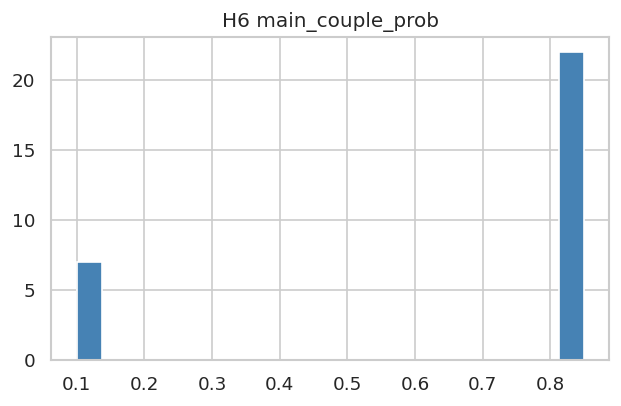

Topics with main_couple_prob < 0.4: 7


,topic,taxonomy,code,code_norm,main_couple_prob
0,121 — Revealing Plans to The Prince,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_0,ARC_0,0.1000
1,130 — Revealing A Secret Plan,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_0,ARC_0,0.1000
2,248 — Arranging A Cover Story,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_10,ARC_10,0.1000
3,286 — Trying to Regain Good Graces,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_0,ARC_0,0.1000
4,346 — Delivering Urgent News in Secret,"4.3 — Secrets, Misunderstandings & Hidden Info...",ARC_0,ARC_0,0.1000
5,256 — Refusing to Let It End,"4.4 — Conflict, Distance & Breakup Threats",ARC_0,ARC_0,0.1000
6,316 — Snapping Over Money and Control,"4.4 — Conflict, Distance & Breakup Threats",ARC_0,ARC_0,0.1000


In [4]:
print(h6[["main_couple_prob", "non_couple_prob", "unclear_prob"]].describe())
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(h6["main_couple_prob"].dropna(), bins=20, color="steelblue", edgecolor="white")
ax.set_title("H6 main_couple_prob")
ctx.save_figure(fig, "h6_main_couple_hist")
plt.show()

low_mc = h6[h6["main_couple_prob"].fillna(0) < 0.4].copy()
print(f"Topics with main_couple_prob < 0.4: {len(low_mc)}")
if len(low_mc):
    display(
        rd.annotation_overview(low_mc, CODE_COL, extra_cols=["main_couple_prob"])[
            ["topic", "taxonomy", "code", "code_norm", "main_couple_prob"]
        ]
    )

## 4. Topic × position weights \(W_{tkr}\)

In [5]:
wtkr = nh.load_w_tkr(cfg)
print(f"W_tkr rows: {len(wtkr)}")
if not wtkr.empty:
    wtkr = wtkr.copy()
    wtkr["code_norm"] = wtkr["construct_code"].map(normalize_code)
    display(
        wtkr.groupby(["tertile", "code_norm"], dropna=False)["weight"]
        .mean()
        .unstack(fill_value=0)
        .round(3)
    )
    ctx.save_table(wtkr, "w_tkr_raw")

W_tkr rows: 190


code_norm,ARC_0,ARC_1,ARC_10,ARC_2,ARC_3,ARC_4,ARC_5,ARC_6,ARC_7,ARC_8,ARC_9
tertile,,,,,,,,,,,
begin,0.6010,0.4200,0.5530,0.4180,0.4300,0.2080,0.5300,0.2500,0.0000,0.2900,0.4730
end,0.5850,0.4480,0.4950,0.4300,0.3200,0.3300,0.7200,0.4700,0.1400,0.2970,0.3880
middle,0.6470,0.3330,0.5830,0.4370,0.2080,0.2260,0.4980,0.4030,0.0000,0.0000,0.3040


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/06_h6_arc_semantics_audit/tables/w_tkr_raw.csv  (190 rows)


## 5. Close reading

Force-include low main-couple topics. In the cards, watch tertile tags on sentences:
rising end-conflict that is non-couple should not feed REFINED_RISING the same way
main-couple conflict does.

In [6]:
review_ids = rd.select_review_topics(
    h6,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    force_ids=low_mc["topic_id"].tolist(),
    per_code=3,
    seed=42,
)
packs = rd.show_review_set(
    cfg,
    h6,
    review_ids,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    code_col=CODE_COL,
    max_sentences=10,
)
ctx.save_markdown(
    rd.render_review_markdown(packs, title="H6 arc semantics — close-reading pack"),
    "close_reading_pack",
)
ctx.save_table(
    h6[
        [
            "topic_id",
            "current_topic_label",
            "current_taxonomy_id",
            "current_taxonomy_name",
            "arc_role",
            "code_norm",
            "main_couple_prob",
            "non_couple_prob",
        ]
    ],
    "arc_topic_annotations",
)

Close-reading 29 of 29 topics (disagreements / mixed / manual / stratified sample).

  TOPIC 121 — Revealing Plans to The Prince
  Taxonomy : 4.3 — Secrets, Misunderstandings & Hidden Information
  Code     : ARC_0  (norm: ARC_0)
  Stage08 snippets:
      · she’ll be queen of the roost.” “
      · do you think he’ll really go to the king?”
      · if i let the prince know what is happening, instead of waiting for them to find out,
      · they’ll know i’ve been out on my own.
  Novel sentences:
    · [BOOK_001, CELL_C, tertile=middle, p=0.49]
        I am not Prince Charming or a shining Knight on a white horse.
    · [BOOK_001, CELL_C, tertile=middle, p=0.40]
        Hot as a fever, rattling bones I could just taste it, taste it If it’s not forever,
        if it’s just tonight Oh it’s still the greatest, the greatest, the greatest Kings of
        Leon Chapter Ten “You two pieces of shit are worthless you know that?”
    · [BOOK_001, CELL_C, tertile=end, p=0.38]
        I WILL one da

  TOPIC 214 — Demanding to Know What Happened
  Taxonomy : 4.3 — Secrets, Misunderstandings & Hidden Information
  Code     : ARC_1  (norm: ARC_1)
  Stage08 snippets:
      · oh my god, how did this happen?”
      · please, tell me precisely what is happening to you.”
      · and i need to know what’s going on to some extent so i don’t think the worst.
  Novel sentences:
    · [BOOK_002, CELL_D, tertile=end, p=0.71]
        Damn you…tell me what happened!”
    · [BOOK_002, CELL_D, tertile=middle, p=0.67]
        What the hell has she done?”
    · [BOOK_002, CELL_D, tertile=middle, p=0.70]
        What has happened to you?”
  Pass A/B/C:
    A lexical: ARC_2
        KeyBERT, POS, and MMR all converge on escalation cues: 'caused/causing' (active
        harm in progress), 'worst' (peak negative intensity), 'extent' (measuring
        severity of damage), and 'precisely/honestly' (confrontational demand for
        truth). Main keywords ('hell, fuck, what happened, going, happening') are


Later: REFINED_FALLING / REFINED_RISING deltas and RARC; EXTERNAL_PLOT_CONFLICT kept
outside the arc equation.

print("H6 audit review complete.")